<a href="https://colab.research.google.com/github/diptu/ml-log/blob/main/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is [Perceptron](https://media.geeksforgeeks.org/wp-content/uploads/20251209120638608023/bhu.webp)

A Perceptron is the simplest form of a neural network that makes decisions by combining inputs with weights and applying an activation function. It is mainly used for binary classification problems. It forms the basic building block of many deep learning models.

- Takes multiple inputs and assigns weights
- Computes a weighted sum and applies a threshold
- Outputs either 0 or 1 (binary outcome)
- Forms the foundation of larger neural networks



# Problem Statement

Given a student's attendance, lab performance, quiz performance, midterm score, and project score, build a simple Artificial Neural Network (ANN) that predicts whether the student will Pass or Fail the course.

The purpose is to understand the complete ANN learning process by hand, including forward propagation, loss calculation, backpropagation, and weight updates.

Input Variables

We will use information available before the final examination:

X=[Attendance, Lab, Quiz, Mid, Project,Bonus]

| Feature    | Maximum |
| ---------- | ------: |
| Attendance |       5 |
| Lab Work   |      20 |
| Quiz       |      20 |
| Mid        |      20 |
| Project    |      10 |
|Bonus			 |		2		|

Target Variable

Convert the final Grade into a binary target:

y={1,0}, Pass=1, Fail=0
	​



## Let's solve this problem with Perceptron


In [19]:
from google.colab import drive
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# 2. Load the CSV file
# Based on your folder, the path is likely:
file_path = '/content/drive/MyDrive/ML-log/data/CSE115.9.csv'
df = pd.read_csv(file_path)

# Display the first few rows to confirm
df.head()

,SI,ID,Attendance (5%),Lab work(20%),Quiz (20 %),Mid (20%),Final(25%),Project(10%),Bonus(2),Total (100%),Grade
0,1,2513658,5.0,15.0,20.0,10.0,23.75,7.0,NaN,81,B-
1,2,2512791,5.0,20.0,18.5,14.0,25.00,8.0,NaN,91,A-
2,3,2512646,5.0,0.0,2.0,7.0,3.75,3.0,NaN,21,F
3,4,2511905,5.0,20.0,20.0,17.0,18.75,9.0,NaN,90,A-
4,5,2513021,5.0,13.0,5.5,10.0,18.75,6.0,NaN,59,F


In [21]:
import pandas as pd


# 1. Define a mapping for the columns you want to rename
# We match the current messy names to your requested clean names
# Note: Original `rename_dict` is kept for reference of desired names.
original_rename_map = {
    'Attendance (5%)': 'Attendance',
    'Lab work(20%)': 'Lab',
    'Quiz (20 %)': 'Quiz',
    'Mid (20%)': 'Mid',
    'Project(10%)': 'Project',
    'Bonus(2)': 'Bonus',
    'Grade  ': 'Grade'
}

# 2. First, strip all column names of the DataFrame to ensure consistency
# This removes any hidden leading/trailing spaces.
df.columns = df.columns.str.strip()

# 3. Create a new rename_dict that maps the *stripped* original names to the desired new names
# This ensures the keys in `rename_dict` perfectly match the now-stripped column names.
rename_dict = {}
for old_name, new_name in original_rename_map.items():
    rename_dict[old_name.strip()] = new_name

# 4. Rename the columns using the adjusted dictionary
df = df.rename(columns=rename_dict)

# 5. Keep only the requested columns
df = df[['Attendance', 'Lab', 'Quiz', 'Mid', 'Project', 'Bonus','Grade']]

# Display the result
df.head()

,Attendance,Lab,Quiz,Mid,Project,Bonus,Grade
0,5.0,15.0,20.0,10.0,7.0,NaN,B-
1,5.0,20.0,18.5,14.0,8.0,NaN,A-
2,5.0,0.0,2.0,7.0,3.0,NaN,F
3,5.0,20.0,20.0,17.0,9.0,NaN,A-
4,5.0,13.0,5.5,10.0,6.0,NaN,F


In [22]:
import numpy as np

# Create the 'passed' column based on the 'Grade' column
df['passed'] = np.where(df['Grade'] == 'F', 0, 1)

# Display the DataFrame with the new column
df.head()

,Attendance,Lab,Quiz,Mid,Project,Bonus,Grade,passed
0,5.0,15.0,20.0,10.0,7.0,NaN,B-,1
1,5.0,20.0,18.5,14.0,8.0,NaN,A-,1
2,5.0,0.0,2.0,7.0,3.0,NaN,F,0
3,5.0,20.0,20.0,17.0,9.0,NaN,A-,1
4,5.0,13.0,5.5,10.0,6.0,NaN,F,0


In [23]:
df = df.fillna(0)
df.head()

,Attendance,Lab,Quiz,Mid,Project,Bonus,Grade,passed
0,5.0,15.0,20.0,10.0,7.0,0.0,B-,1
1,5.0,20.0,18.5,14.0,8.0,0.0,A-,1
2,5.0,0.0,2.0,7.0,3.0,0.0,F,0
3,5.0,20.0,20.0,17.0,9.0,0.0,A-,1
4,5.0,13.0,5.5,10.0,6.0,0.0,F,0


In [24]:
df['Bonus'].max()

2.0

In [26]:
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Select a random row from the DataFrame
random_row = df.sample(n=1)

# Display the random row
print(random_row)

    Attendance   Lab  Quiz   Mid  Project  Bonus Grade  passed
33         5.0  20.0  20.0  16.0      8.0    1.0     A       1


<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_968/443462962.py:45: SyntaxWarning: invalid escape sequence '\s'
  ax.text((x_sigmoid + x_output) / 2, y_sigmoid + 0.25, "Sigmoid ($a = \sigma(z)$)", fontsize=10, color="#333333", ha='center', va='bottom')


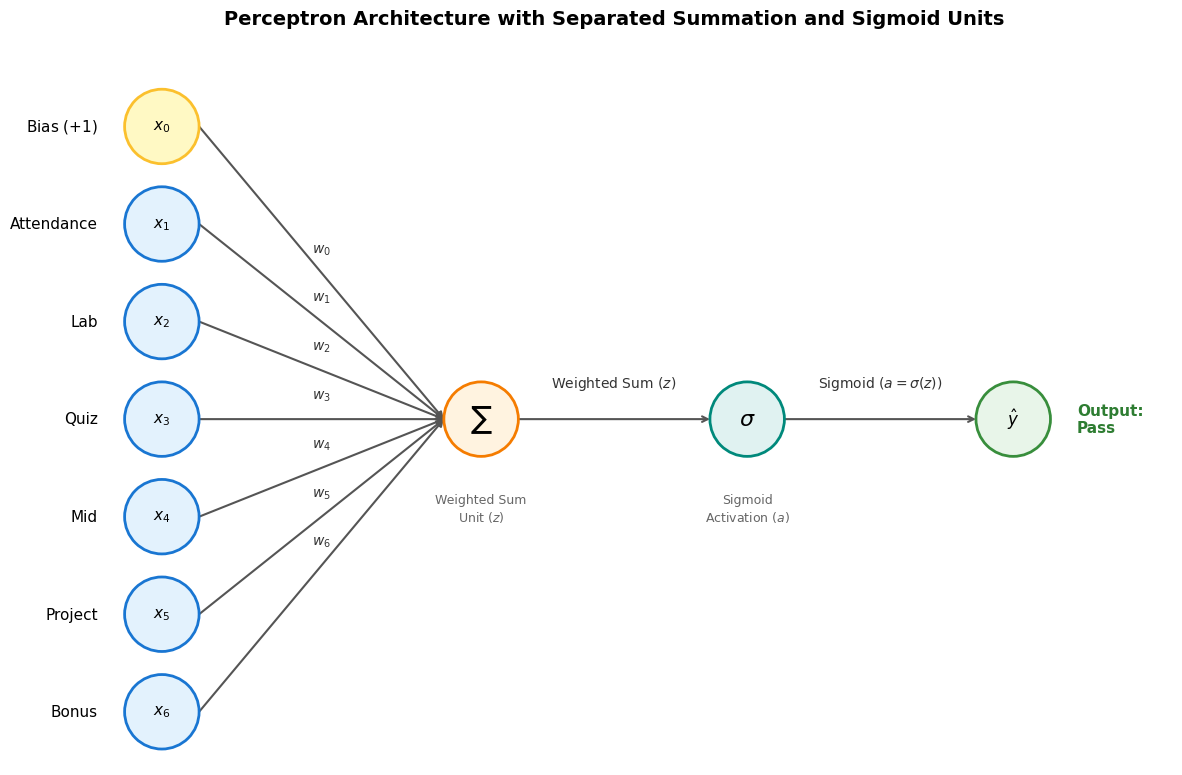

Separated perceptron diagram generated.


In [39]:
import matplotlib.pyplot as plt
import numpy as np

def draw_perceptron_separated():
    # Define inputs including bias as the first element
    inputs = ['Bias ($+1$)', 'Attendance', 'Lab', 'Quiz', 'Mid', 'Project', 'Bonus']
    output_label = 'Output:\nPass'

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_aspect('equal')
    ax.axis('off')

    # Coordinates (Adjusted for separation)
    x_input = 1.0
    x_sum = 4.0
    x_sigmoid = 6.5
    x_output = 9.0

    y_inputs = np.linspace(5.5, 0.0, len(inputs))
    y_sum = 2.75
    y_sigmoid = 2.75
    y_output = 2.75

    node_radius = 0.35

    # 1. Draw connections from inputs to SUMMATION node
    for i, y in enumerate(y_inputs):
        ax.annotate("", xy=(x_sum - node_radius, y_sum), xytext=(x_input + node_radius, y),
                    arrowprops=dict(arrowstyle="->", color="#555555", lw=1.5, shrinkA=0, shrinkB=0, connectionstyle="arc3"))

        mid_x = (x_input + x_sum) / 2
        mid_y = (y + y_sum) / 2 + 0.15
        weight_label = "$w_0$" if i == 0 else f"$w_{{{i}}}$"
        ax.text(mid_x, mid_y, weight_label, fontsize=10, color="#333333", ha='center', va='bottom',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.8))

    # 2. Draw connection from SUMMATION node to SIGMOID node
    ax.annotate("", xy=(x_sigmoid - node_radius, y_sigmoid), xytext=(x_sum + node_radius, y_sum),
                arrowprops=dict(arrowstyle="->", color="#555555", lw=1.5, shrinkA=0, shrinkB=0))
    ax.text((x_sum + x_sigmoid) / 2, y_sum + 0.25, "Weighted Sum ($z$)", fontsize=10, color="#333333", ha='center', va='bottom')

    # 3. Draw connection from SIGMOID node to OUTPUT node
    ax.annotate("", xy=(x_output - node_radius, y_output), xytext=(x_sigmoid + node_radius, y_sigmoid),
                arrowprops=dict(arrowstyle="->", color="#555555", lw=1.5, shrinkA=0, shrinkB=0))
    ax.text((x_sigmoid + x_output) / 2, y_sigmoid + 0.25, "Sigmoid ($a = \sigma(z)$)", fontsize=10, color="#333333", ha='center', va='bottom')

    # 4. Draw Input Nodes (Bias highlighted distinctly)
    for i, (name, y) in enumerate(zip(inputs, y_inputs)):
        face_color = '#FFF9C4' if i == 0 else '#E3F2FD'
        edge_color = '#FBC02D' if i == 0 else '#1976D2'
        circle = plt.Circle((x_input, y), node_radius, facecolor=face_color, edgecolor=edge_color, lw=2, zorder=3)
        ax.add_patch(circle)
        node_label = "$x_0$" if i == 0 else f"$x_{{{i}}}$"
        ax.text(x_input, y, node_label, fontsize=11, fontweight='bold', ha='center', va='center', zorder=4)
        ax.text(x_input - 0.6, y, name, fontsize=11, fontweight='medium', ha='right', va='center')

    # 5. Draw Summation Node (Separated)
    sum_circle = plt.Circle((x_sum, y_sum), node_radius, facecolor='#FFF3E0', edgecolor='#F57C00', lw=2, zorder=3)
    ax.add_patch(sum_circle)
    ax.text(x_sum, y_sum, r"$\sum$", fontsize=16, fontweight='bold', ha='center', va='center', zorder=4)
    ax.text(x_sum, y_sum - 0.7, "Weighted Sum\nUnit ($z$)", fontsize=9, color='#666666', ha='center', va='top')

    # 6. Draw Sigmoid Node (Separated)
    sigmoid_circle = plt.Circle((x_sigmoid, y_sigmoid), node_radius, facecolor='#E0F2F1', edgecolor='#00897B', lw=2, zorder=3)
    ax.add_patch(sigmoid_circle)
    ax.text(x_sigmoid, y_sigmoid, r"$\sigma$", fontsize=16, fontweight='bold', ha='center', va='center', zorder=4)
    ax.text(x_sigmoid, y_sigmoid - 0.7, "Sigmoid\nActivation ($a$)", fontsize=9, color='#666666', ha='center', va='top')

    # 7. Draw Output Node
    output_circle = plt.Circle((x_output, y_output), node_radius, facecolor='#E8F5E9', edgecolor='#388E3C', lw=2, zorder=3)
    ax.add_patch(output_circle)
    ax.text(x_output, y_output, r"$\hat{y}$", fontsize=12, fontweight='bold', ha='center', va='center', zorder=4)
    ax.text(x_output + 0.6, y_output, output_label, fontsize=11, fontweight='bold', color='#2E7D32', ha='left', va='center')

    # Title & Layout adjustments
    plt.title("Perceptron Architecture with Separated Summation and Sigmoid Units", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlim(0.0, 10.5)
    ax.set_ylim(-0.5, 6.2)

    plt.tight_layout()
    plt.savefig('perceptron_separated.png', bbox_inches='tight')
    plt.show()
    print("Separated perceptron diagram generated.")

draw_perceptron_separated()

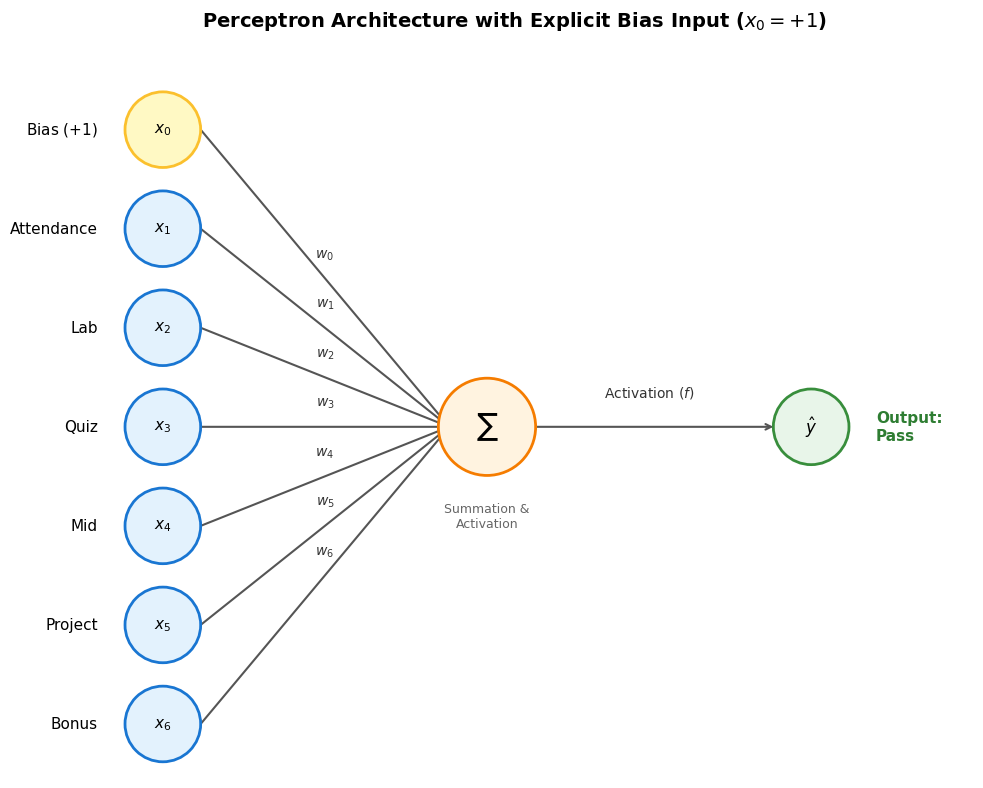

In [32]:
draw_perceptron()

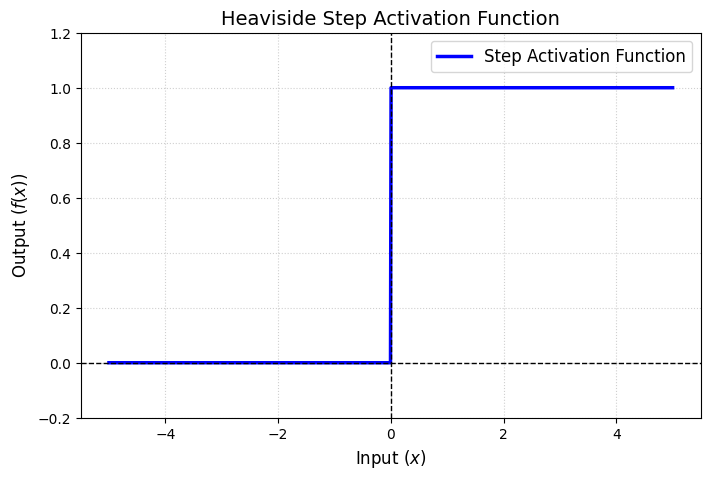

Plot generated successfully.


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data for step function (Heaviside step function)
x = np.linspace(-5, 5, 1000)
y = np.where(x >= 0, 1, 0)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Step Activation Function', color='blue', linewidth=2.5)
plt.title('Heaviside Step Activation Function', fontsize=14)
plt.xlabel('Input ($x$)', fontsize=12)
plt.ylabel('Output ($f(x)$)', fontsize=12)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(-0.2, 1.2)
plt.legend(fontsize=12)

# Save plot
plt.savefig('step_function.png', bbox_inches='tight')
plt.show()
print("Plot generated successfully.")

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_968/443462962.py:45: SyntaxWarning: invalid escape sequence '\s'
  ax.text((x_sigmoid + x_output) / 2, y_sigmoid + 0.25, "Sigmoid ($a = \sigma(z)$)", fontsize=10, color="#333333", ha='center', va='bottom')


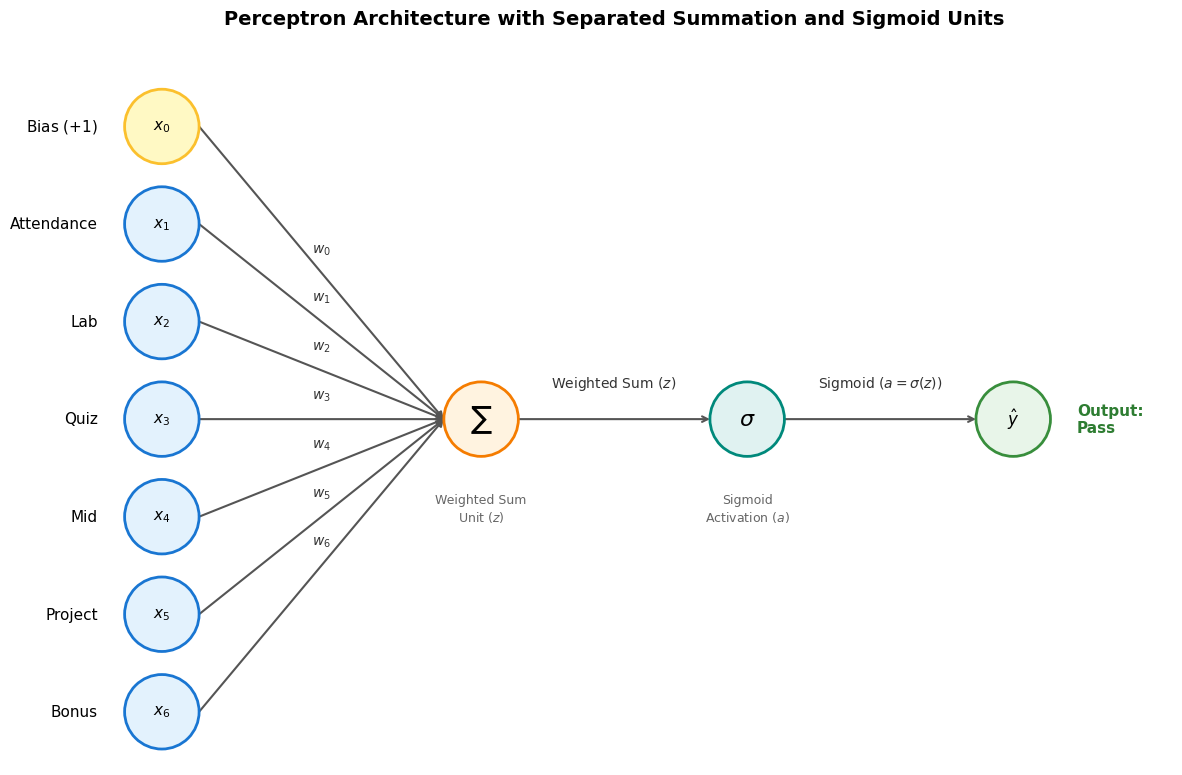

Separated perceptron diagram generated.
